## <div align="center"> LAB IS411 Data Modeling </div>
## <div align="center"> UAS</div>
#### <div align="center"> Even Semester 2023/2024 </div>
---

Dataset bersumber dari kaggle dengan link : https://www.kaggle.com/datasets/aankasman/acled-protests-violence-in-indonesia-20152019/data. Dataset ini berisi jenis kejadian di Indonesia terkait kerusuhan, seperti konflik, protes, atau kejadian signifikan lainnya, dan menangkap informasi detail tentang kejadian tersebut, termasuk aktor yang terlibat, lokasi, tanggal, dan sumber informasi.

1. *iso*: Kode numerik yang mewakili Indonesia.
2. *event_id_cnty*: Pengidentifikasi unik untuk setiap kejadian, menggabungkan nomor dan akronim negara (contoh: IDN untuk Indonesia).
3. *event_id_no_cnty*: Pengidentifikasi numerik unik untuk setiap kejadian.
4. *event_date*: Tanggal kejadian tersebut terjadi, diformat sebagai Hari/Bulan/Tahun.
5. *year*: Tahun terjadinya kejadian.
6. *time_precision*: Kode numerik (1-3) yang menunjukkan tingkat kepastian tanggal kejadian.
7. *event_type*: Jenis utama dari kejadian (misalnya, Protes, Kerusuhan, Pertempuran).
8. *sub_event_type*: Sub-jenis spesifik dari kejadian (misalnya, Protes Damai, Serangan).
9. *actor1*: Aktor utama yang terlibat dalam kejadian (misalnya, Demonstran, Polisi).
10. *assoc_actor_1*: Aktor terkait yang berhubungan dengan ACTOR1 dalam kejadian tertentu.
11. *inter1*: Kode numerik yang mewakili jenis dari ACTOR1.
12. *interaction*: jumlah kejadian dengan interaksi.
13. *region*: Wilayah di dunia di mana kejadian terjadi (dalam konteks ini, bagian-bagian Indonesia).
14. *country*: Negara di mana kejadian terjadi (Indonesia).
15. *admin1*: Wilayah administratif sub-nasional terbesar di mana kejadian terjadi (misalnya, provinsi di Indonesia).
16. *admin2*: Wilayah administratif sub-nasional terbesar kedua di mana kejadian terjadi (misalnya, kabupaten atau kota di Indonesia).
17. *admin3*: Wilayah administratif sub-nasional terbesar ketiga di mana kejadian terjadi (misalnya, kecamatan di Indonesia).
18. *location*: Lokasi spesifik di mana kejadian terjadi.
19. *latitude*: Koordinat lintang dari lokasi kejadian.
20. *longitude*: Koordinat bujur dari lokasi kejadian.
21. *geo_precision*: Kode numerik yang menunjukkan tingkat kepastian lokasi kejadian.
22. *source*: Sumber informasi yang digunakan untuk mencatat kejadian tersebut (misalnya, media berita).
23. *source_scale*: Skala geografis dari sumber yang digunakan untuk mencatat kejadian tersebut.
24. *notes*: Deskripsi singkat mengenai kejadian tersebut.
25. *fatalities*: Jumlah atau perkiraan korban jiwa akibat kejadian tersebut.
26. *timestamp*: Stempel waktu yang menunjukkan kapan data kejadian tersebut dicatat.
27. *iso3*: Kode negara ISO 3166-1 alpha-3 untuk Indonesia (IDN).
tanggal, dan sumber informasi.

In [46]:
import datetime
import uuid

studentName = "Angel Lawrensia, Advendhita Putri Cahyani, Muhammad Farhan Zaky, Nova Indah Lumbantoruan"
studentNIM = "84325, 79028, 83525, 81152"
studentClass = "CL"

In [2]:
print("Name: \t\t{}".format(studentName))
print("NIM: \t\t{}".format(studentNIM))

Name: 		Angel Lawrensia, Advendhita Putri Cahyani, Muhammad Farhan Zaky, Nova Indah Lumbantoruan
NIM: 		84325, 79028, 83525, 81152


In [3]:
myDate = datetime.datetime.now()
myDevice = str(uuid.uuid1())

print("Class: \t\t{}".format(studentClass))
print("Start: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Class: 		Cl
Start: 		2024-05-15 23:15:56.575554
Device ID: 	69011894-12d6-11ef-80aa-2c3b7007340a


---

## <div align="center"> BUSINESS UNDERSTANDING </div>

Penelitian ini bertujuan untuk menganalisis pola dan karakteristik dari demonstrasi dan kerusuhan di Indonesia dengan memanfaatkan teknik clustering, khususnya K-Means dan DBSCAN (Density-Based Spatial Clustering of Applications with Noise). Hasil analisis ini diharapkan dapat dimanfaatkan oleh pemerintah dan pihak berwenang dalam mengidentifikasi kerusuhan berdasarkan tingkat kematian dan jumlah interaksi.


## <div align="center"> DATA UNDERSTANDING </div>

### Enter Lab Code Here:

1. Import Library yang dibutuhkan

In [36]:
import os
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.cluster.hierarchy as sch
import sklearn.utils
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

#Untuk Evaluasi
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

2. Membaca dataset & melakukan eksplorasi dataset

In [37]:
data = pd.read_csv("C:\\Kampus UMN\\Data Modelling\\UAS\\2015-01-01-2019-01-31-South-Eastern_Asia-Indonesia.csv")
data.head(5)

,data_id,iso,event_id_cnty,event_id_no_cnty,event_date,year,time_precision,event_type,sub_event_type,actor1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,timestamp,iso3
0,5590925,360,IDN520,520,31 January 2019,2019,1,Battles,Armed clash,TPNPB: West Papua National Liberation Army,...,Mapenduma,-4.3887,138.2340,1,Jakarta Post,National,"On January 31, 2019, in Mapenduma village (Ndu...",0,1563366749,IDN
1,5590925,360,IDN520,520,31 January 2019,2019,1,Battles,Armed clash,Military Forces of Indonesia (2014-),...,Mapenduma,-4.3887,138.2340,1,Jakarta Post,National,"On January 31, 2019, in Mapenduma village (Ndu...",0,1563366749,IDN
2,6301918,360,IDN526,526,31 January 2019,2019,1,Violence against civilians,Attack,Police Forces of Indonesia (2014-),...,Wamena,-4.0951,138.9449,1,Pattaya One,Regional,"On 31 January 2019, a Polish man in the police...",0,1572403769,IDN
3,6301918,360,IDN526,526,31 January 2019,2019,1,Violence against civilians,Attack,Civilians (Poland),...,Wamena,-4.0951,138.9449,1,Pattaya One,Regional,"On 31 January 2019, a Polish man in the police...",0,1572403769,IDN
4,5590924,360,IDN519,519,30 January 2019,2019,1,Protests,Peaceful protest,Protesters (Indonesia),...,Lebak Bulus,-6.3037,106.7800,1,Jakarta Post,National,"On January 30, 2019, in Lebak Bulus village of...",0,1563366749,IDN


In [38]:
print(data) #untuk melihat secara keseluruhan

      data_id  iso event_id_cnty  event_id_no_cnty       event_date  year  \
0     5590925  360        IDN520               520  31 January 2019  2019   
1     5590925  360        IDN520               520  31 January 2019  2019   
2     6301918  360        IDN526               526  31 January 2019  2019   
3     6301918  360        IDN526               526  31 January 2019  2019   
4     5590924  360        IDN519               519  30 January 2019  2019   
...       ...  ...           ...               ...              ...   ...   
3116  6663271  360       IDN2299              2299  01 January 2015  2015   
3117  6662768  360        IDN238               238  01 January 2015  2015   
3118  6662768  360        IDN238               238  01 January 2015  2015   
3119  6663554  360       IDN2300              2300  01 January 2015  2015   
3120  6663554  360       IDN2300              2300  01 January 2015  2015   

      time_precision                  event_type             sub_event_type

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3121 entries, 0 to 3120
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_id           3121 non-null   int64  
 1   iso               3121 non-null   int64  
 2   event_id_cnty     3121 non-null   object 
 3   event_id_no_cnty  3121 non-null   int64  
 4   event_date        3121 non-null   object 
 5   year              3121 non-null   int64  
 6   time_precision    3121 non-null   int64  
 7   event_type        3121 non-null   object 
 8   sub_event_type    3121 non-null   object 
 9   actor1            3121 non-null   object 
 10  assoc_actor_1     1728 non-null   object 
 11  inter1            3121 non-null   int64  
 12  interaction       3121 non-null   int64  
 13  region            3121 non-null   object 
 14  country           3121 non-null   object 
 15  admin1            3121 non-null   object 
 16  admin2            3121 non-null   object 


Dataset ini memiliki 3121 baris dan 28 kolom dengan tipe data float64 sebanyak 2, int64 sebanyak 10, dan object sebanyak 16

In [40]:
data.describe()

,data_id,iso,event_id_no_cnty,year,time_precision,inter1,interaction,latitude,longitude,geo_precision,fatalities,timestamp
count,3.121000e+03,3121.0,3121.000000,3121.000000,3121.000000,3121.000000,3121.000000,3121.000000,3121.000000,3121.000000,3121.000000,3.121000e+03
mean,6.405315e+06,360.0,1941.428068,2016.672220,1.040051,4.701378,39.115027,-4.113937,116.899062,1.129446,0.239026,1.573527e+09
std,4.809030e+05,0.0,1121.081963,1.279233,0.227862,2.185594,21.485920,3.558937,13.853095,0.369383,1.008249,5.912028e+06
min,4.598209e+06,360.0,1.000000,2015.000000,1.000000,1.000000,10.000000,-10.170800,95.212700,1.000000,0.000000,1.552576e+09
25%,6.270999e+06,360.0,616.000000,2015.000000,1.000000,3.000000,16.000000,-6.822200,106.809000,1.000000,0.000000,1.572404e+09
50%,6.663374e+06,360.0,2316.000000,2017.000000,1.000000,6.000000,55.000000,-5.148600,112.543200,1.000000,0.000000,1.576600e+09
75%,6.664103e+06,360.0,2867.000000,2018.000000,1.000000,6.000000,60.000000,-2.533700,131.261000,1.000000,0.000000,1.576600e+09
max,6.712526e+06,360.0,3414.000000,2019.000000,3.000000,8.000000,78.000000,5.892500,140.862800,3.000000,19.000000,1.578511e+09


In [41]:
data.isnull().sum()

data_id                0
iso                    0
event_id_cnty          0
event_id_no_cnty       0
event_date             0
year                   0
time_precision         0
event_type             0
sub_event_type         0
actor1                 0
assoc_actor_1       1393
inter1                 0
interaction            0
region                 0
country                0
admin1                 0
admin2                 0
admin3                 0
location               0
latitude               0
longitude              0
geo_precision          0
source                 0
source_scale           0
notes                  0
fatalities             0
timestamp              0
iso3                   0
dtype: int64

Terdapat missing value pada assoc_actor_1 sebesar 1393

3. Melihat korelasi antar kolom

                   data_id  iso  event_id_no_cnty      year  time_precision  \
data_id           1.000000  NaN          0.791212 -0.038204       -0.015880   
iso                    NaN  NaN               NaN       NaN             NaN   
event_id_no_cnty  0.791212  NaN          1.000000 -0.051447       -0.044069   
year             -0.038204  NaN         -0.051447  1.000000       -0.047312   
time_precision   -0.015880  NaN         -0.044069 -0.047312        1.000000   
inter1            0.086717  NaN          0.099018  0.046372       -0.045483   
interaction       0.041878  NaN          0.050561  0.086953       -0.090172   
latitude          0.058235  NaN          0.060486 -0.041968        0.034775   
longitude         0.061933  NaN          0.039353 -0.069498        0.091884   
geo_precision    -0.146558  NaN         -0.124849  0.021992        0.094512   
fatalities       -0.116968  NaN         -0.163920  0.021004        0.058764   
timestamp         0.997034  NaN          0.775970 -0

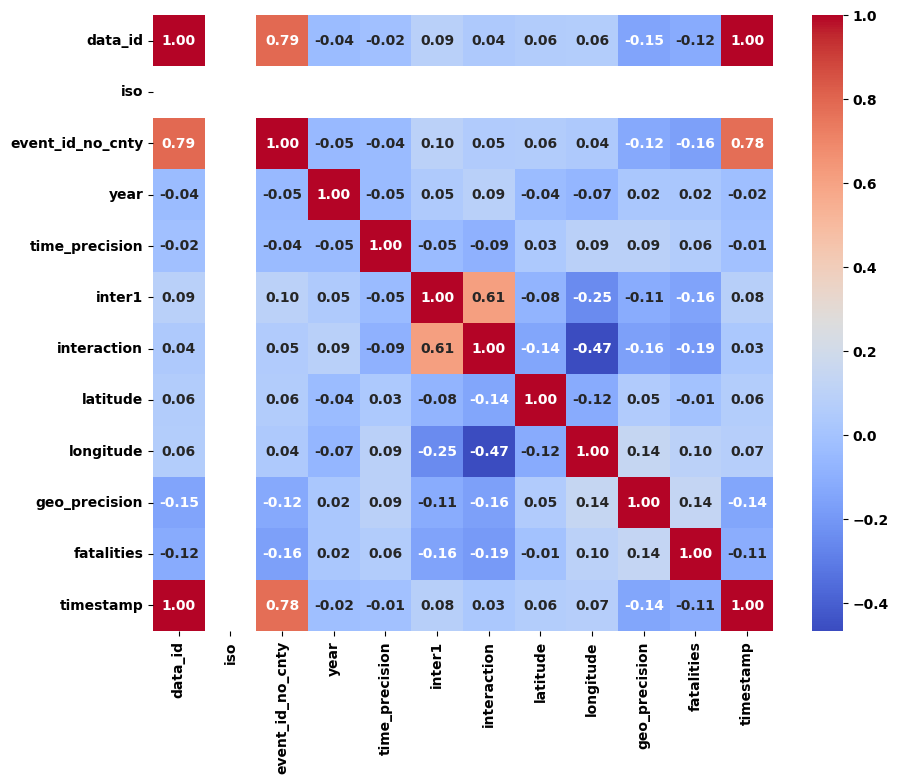

In [42]:
df = pd.DataFrame(data)

# Memilih hanya kolom numerik
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Menghitung korelasi
correlation_matrix = df_numeric.corr()

# Menampilkan matriks korelasi
print(correlation_matrix)

# Membuat heatmap dari matriks korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

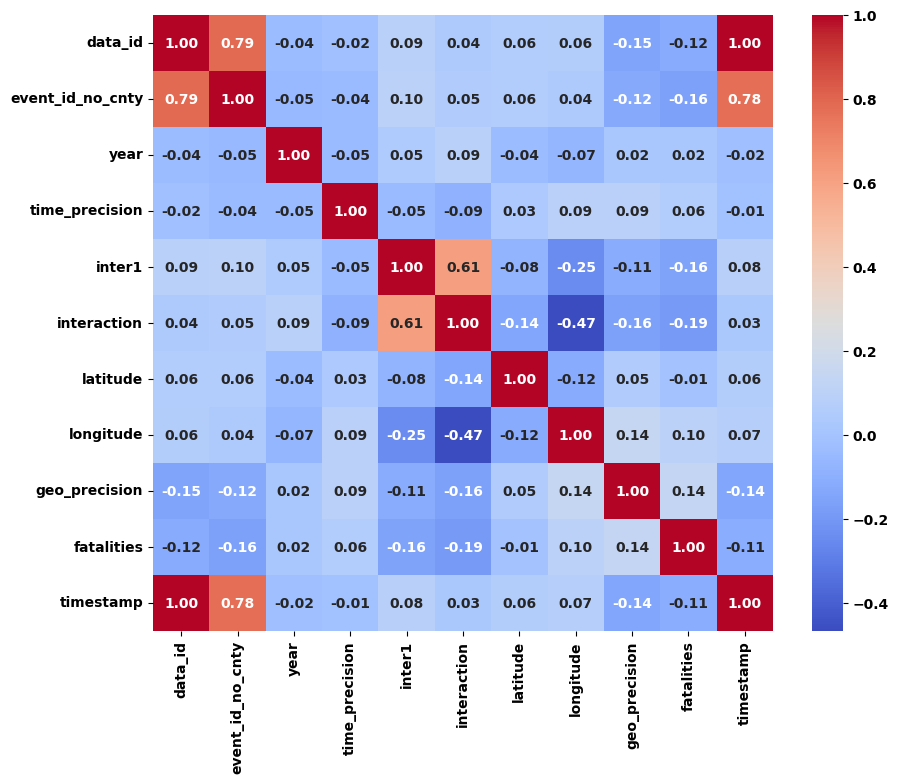

In [43]:
# Menghapus kolom yang mengandung NaN di matriks korelasi jika tidak diperlukan
correlation_matrix = correlation_matrix.dropna(axis=1, how='all')
correlation_matrix = correlation_matrix.dropna(axis=0, how='all')

# Membuat heatmap dari matriks korelasi yang sudah dibersihkan
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

Dari korelasi heatmap, didapatkan fitur yang memiliki hubungan kuat yaitu pada inter1 dengan interaction, dan event_id_no_cnty dengan data_id, timestamp.

4. Visualisasi

<Axes: title={'center': 'Jumlah fatalities pada kejadian'}, xlabel='fatalities', ylabel='count'>

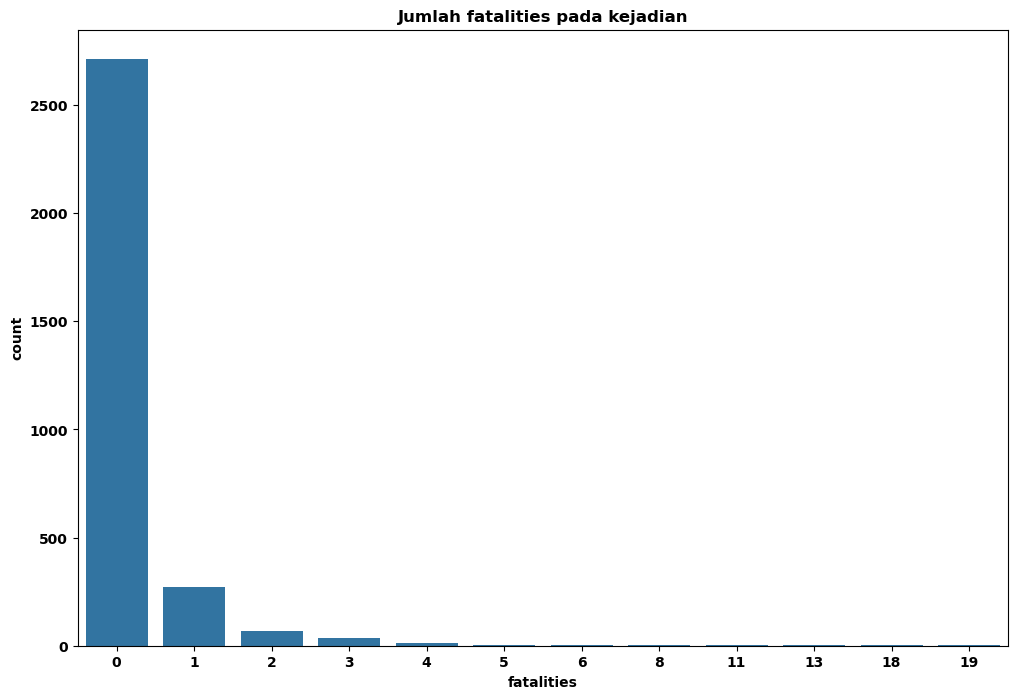

In [44]:
# Hitung jumlah kejadian untuk setiap fatalities
event_counts = data['fatalities'].value_counts().reset_index()
event_counts.columns = ['fatalities', 'count']

fig, ax = plt.subplots(figsize=(12, 8))
plt.title("Jumlah fatalities pada kejadian")

# Buat bar plot
sns.barplot(x="fatalities", y="count", data=event_counts, ax=ax)

Dari hasil dapat disimpulkan paling banyak pada kejadian itu tidak memakan korban jiwa

<Axes: title={'center': 'Jumlah interaksi pada kejadian'}, xlabel='interaction', ylabel='count'>

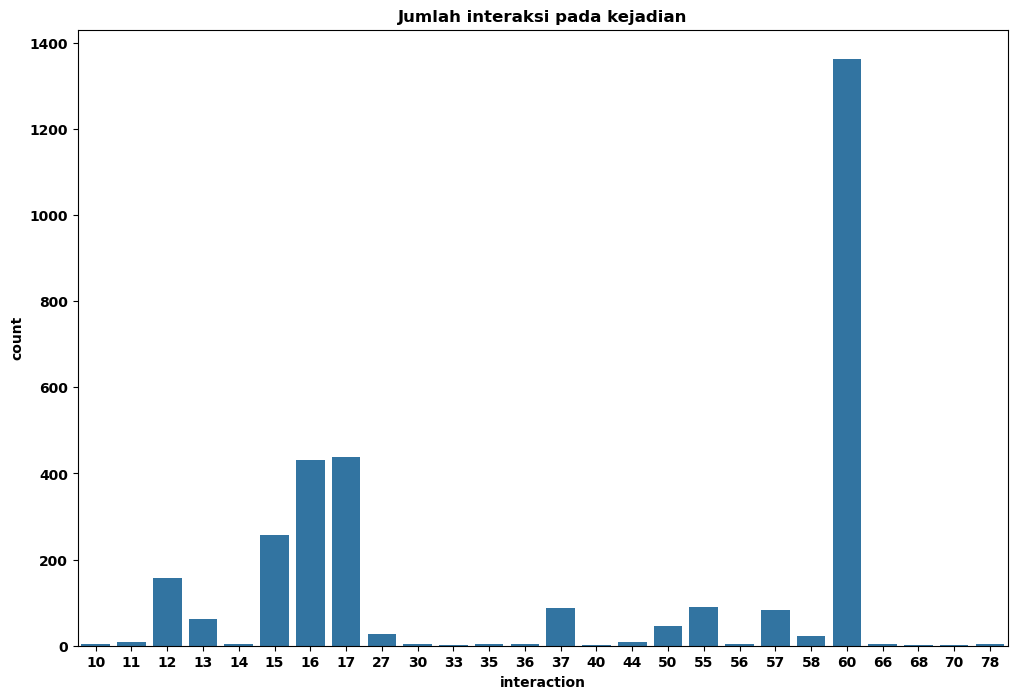

In [45]:
# Hitung jumlah kejadian untuk setiap interaction
event_counts = data['interaction'].value_counts().reset_index()
event_counts.columns = ['interaction', 'count']

fig, ax = plt.subplots(figsize=(12, 8))
plt.title("Jumlah interaksi pada kejadian")
# Buat bar plot
sns.barplot(x="interaction", y="count", data=event_counts, ax=ax)

Dari hasil grafik dapat diketahui jumlah kejadian interaksi cenderung terjadi di angka 60

5. Pengecekkan Outlier

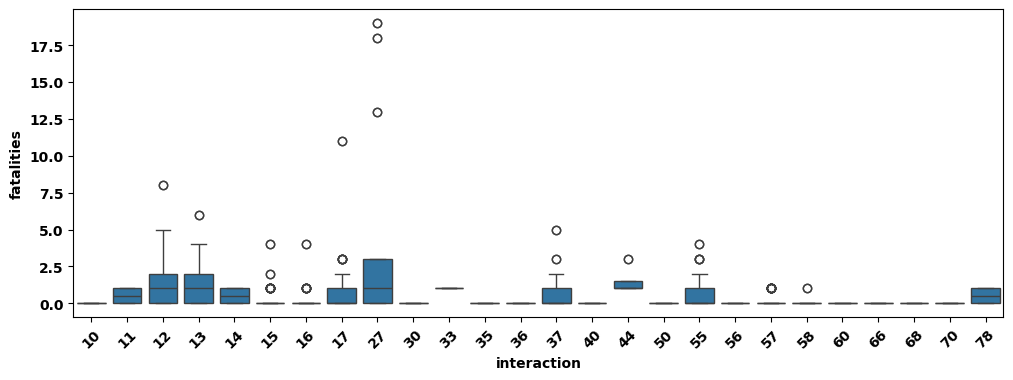

In [46]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(x="interaction", y="fatalities", data=data, orient='v', ax=ax)
plt.xticks(rotation=45)

plt.show()

Terdapat outlier yang cukup banyak pada kedua kolom

## <div align="center"> DATA PREPARATION </div>

6. Penanganan Missing Values

In [47]:
data['assoc_actor_1'].fillna('Unknown', inplace=True)

In [48]:
data.isnull().sum()

data_id             0
iso                 0
event_id_cnty       0
event_id_no_cnty    0
event_date          0
year                0
time_precision      0
event_type          0
sub_event_type      0
actor1              0
assoc_actor_1       0
inter1              0
interaction         0
region              0
country             0
admin1              0
admin2              0
admin3              0
location            0
latitude            0
longitude           0
geo_precision       0
source              0
source_scale        0
notes               0
fatalities          0
timestamp           0
iso3                0
dtype: int64

Dapat terlihat kolom assoc_actor_1 sudah terisi dengan menggunakan metode fillna(). Kami menggunakan fillna() dibandingkan dropna() karena kalau dibuang akan terbuang sekitar setengah dari dataset yang artinya mengurangi banyak dan penanganannya kurang cocok.

7. Penanganan Outlier

In [49]:
# Menghitung mean dan standar deviasi
mean = data['fatalities'].mean()
std_dev = data['fatalities'].std()

# Menghitung Z-score
data['z_score'] = (data['fatalities'] - mean) / std_dev

# Tentukan threshold Z-score (misalnya, 3)
threshold = 3

# Identifikasi outlier
outliers = data[np.abs(data['z_score']) > threshold]

# Hapus outlier dari dataset
cleaned_data = data.drop(outliers.index)

# Tampilkan data tanpa outlier
print(cleaned_data)

      data_id  iso event_id_cnty  event_id_no_cnty       event_date  year  \
0     5590925  360        IDN520               520  31 January 2019  2019   
1     5590925  360        IDN520               520  31 January 2019  2019   
2     6301918  360        IDN526               526  31 January 2019  2019   
3     6301918  360        IDN526               526  31 January 2019  2019   
4     5590924  360        IDN519               519  30 January 2019  2019   
...       ...  ...           ...               ...              ...   ...   
3116  6663271  360       IDN2299              2299  01 January 2015  2015   
3117  6662768  360        IDN238               238  01 January 2015  2015   
3118  6662768  360        IDN238               238  01 January 2015  2015   
3119  6663554  360       IDN2300              2300  01 January 2015  2015   
3120  6663554  360       IDN2300              2300  01 January 2015  2015   

      time_precision                  event_type             sub_event_type

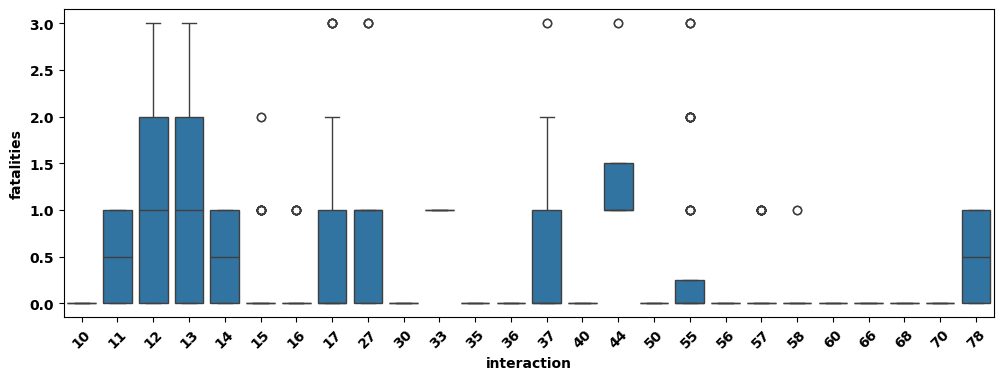

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(x="interaction", y="fatalities", data=cleaned_data, orient='v', ax=ax)
plt.xticks(rotation=45)

plt.show()

Setelah dilakukan penanganan outlier dengan menggunakan metode Z-score dapat terlihat outliernya menjadi lebih sedikit

## <div align="center"> MODELLING </div>

### KMEANS

8. Elbow Methods
Dilakukan untuk mengetahui jumlah kluster yang cocok untuk diaplikasi pada K-Means

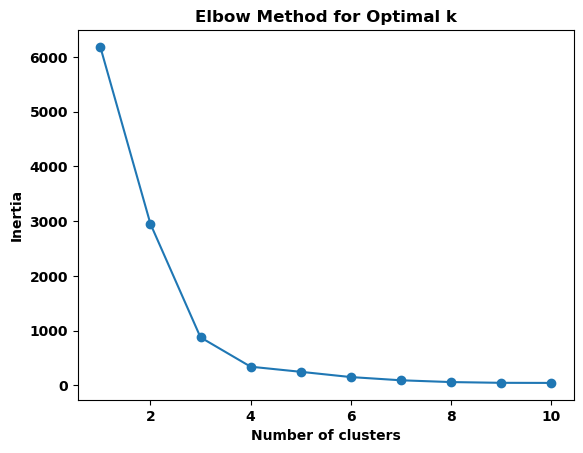

In [51]:
# Asumsikan cleaned_data sudah ada dan telah dibersihkan
# Mengambil subset data
Clus_dataSet = cleaned_data[['interaction', 'fatalities']]

# Normalisasi data
scaler = StandardScaler()
Clus_dataSet_scaled = scaler.fit_transform(Clus_dataSet)

# Mencari inersia untuk berbagai jumlah klaster
inertias = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(Clus_dataSet_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow method
plt.plot(K, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Dapat dilihat lekukkan pada elbow method yang paling baik pada angka 3

9. KMeans Modelling

In [52]:
#K= 3 dari elbow method
k=3
# Melakukan clustering dengan K-Means
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(data[['interaction', 'fatalities']])
data['Clus_Kmeans'] = kmeans.labels_

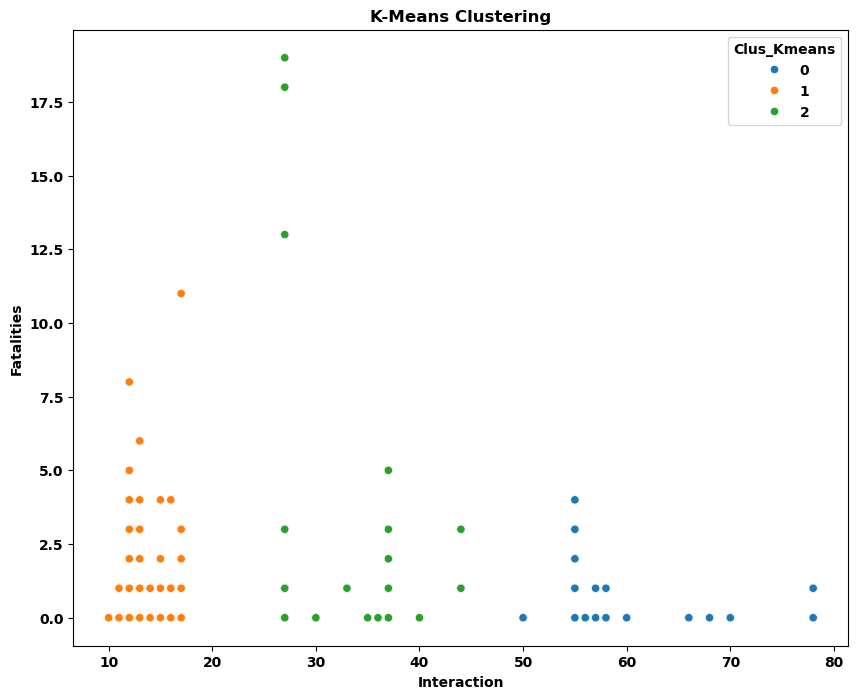

In [53]:
# Visualisasi hasil clustering
plt.figure(figsize=(10, 8))
sns.scatterplot(x='interaction', y='fatalities', hue='Clus_Kmeans', data=data, palette='tab10')
plt.title('K-Means Clustering')
plt.xlabel('Interaction')
plt.ylabel('Fatalities')
plt.show()

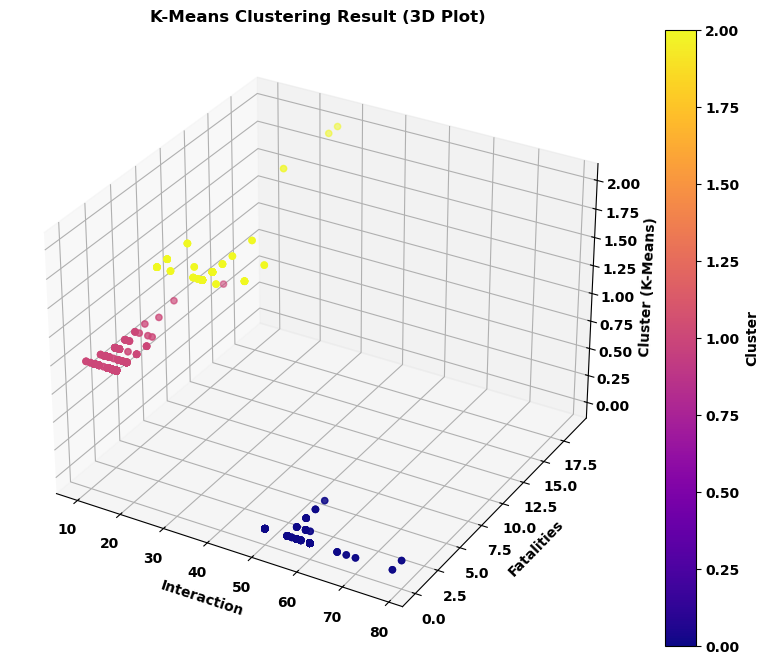

In [54]:
# Definisikan figure
fig = plt.figure(figsize=(10, 8))

# Tambahkan subplot 3D
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
scatter = ax.scatter(data['interaction'], data['fatalities'], data['Clus_Kmeans'], c=data['Clus_Kmeans'], cmap='plasma')

# Label sumbu
ax.set_xlabel('Interaction')
ax.set_ylabel('Fatalities')
ax.set_zlabel('Cluster (K-Means)')

# Judul plot
plt.title('K-Means Clustering Result (3D Plot)')

# Tampilkan colorbar
plt.colorbar(scatter, label='Cluster')

# Tampilkan plot
plt.show()

In [55]:
# Statistik ringkas untuk setiap cluster
cluster_stats = data.groupby('Clus_Kmeans').agg({'interaction': 'mean', 'fatalities': 'mean', 'event_type': 'count'})
cluster_stats.rename(columns={'event_type': 'count'}, inplace=True)
print(cluster_stats)

             interaction  fatalities  count
Clus_Kmeans                                
0              59.327160    0.040741   1620
1              15.480176    0.364170   1362
2              35.136691    1.323741    139


Klaster 0: Terdiri dari sekitar 54.0% dari total data. Klaster ini memiliki tingkat interaksi rata-rata sebesar 59.33 dan tingkat kematian yang rendah sebesar 0.04. Klaster ini merupakan klaster terbesar dalam dataset dan cenderung memiliki interaksi yang tinggi dengan tingkat kematian yang rendah.

Klaster 1: Terdiri dari sekitar 45.4% dari total data. Klaster ini memiliki tingkat interaksi rata-rata sebesar 15.48 dan tingkat kematian yang sedang sebesar 0.36. Klaster ini memiliki tingkat interaksi yang rendah dengan tingkat kematian yang cukup signifikan.

Klaster 2: Terdiri dari sekitar 0.46% dari total data. Klaster ini memiliki tingkat interaksi rata-rata sebesar 35.14 dan tingkat kematian yang tinggi sebesar 1.32. Klaster ini merupakan klaster dengan tingkat interaksi menengah hingga tinggi dengan tingkat kematian yang tinggi pula.

### DBSCAN

10. Melakukan Import Ulang

In [56]:
data = pd.read_csv("C:\\Kampus UMN\\Data Modelling\\UAS\\2015-01-01-2019-01-31-South-Eastern_Asia-Indonesia.csv")

In [57]:
data['assoc_actor_1'].fillna('Unknown', inplace=True)

In [58]:
# Menghitung mean dan standar deviasi
mean = data['fatalities'].mean()
std_dev = data['fatalities'].std()

# Menghitung Z-score
data['z_score'] = (data['fatalities'] - mean) / std_dev

# Tentukan threshold Z-score (misalnya, 3)
threshold = 3

# Identifikasi outlier
outliers = data[np.abs(data['z_score']) > threshold]

# Hapus outlier dari dataset
cleaned_data = data.drop(outliers.index)

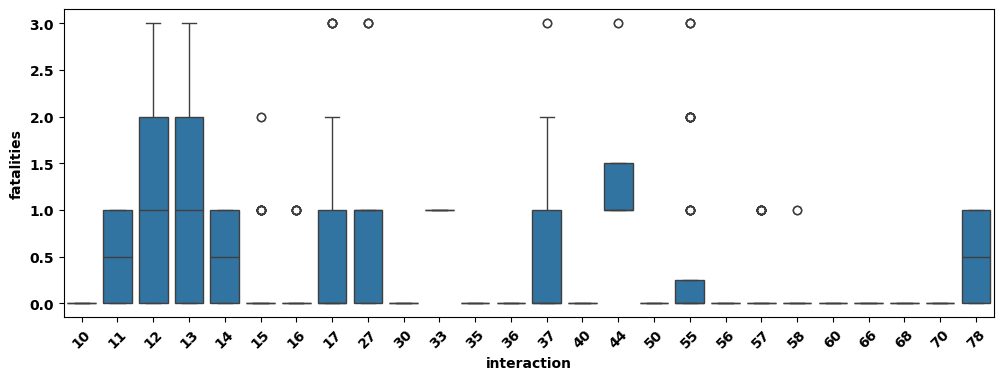

In [59]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(x="interaction", y="fatalities", data=cleaned_data, orient='v', ax=ax)
plt.xticks(rotation=45)

plt.show()

11. Modelling

In [60]:
db = DBSCAN(eps=8, min_samples=2).fit(data[['interaction', 'fatalities']])
labels = db.labels_
data['Clus_Db'] = labels

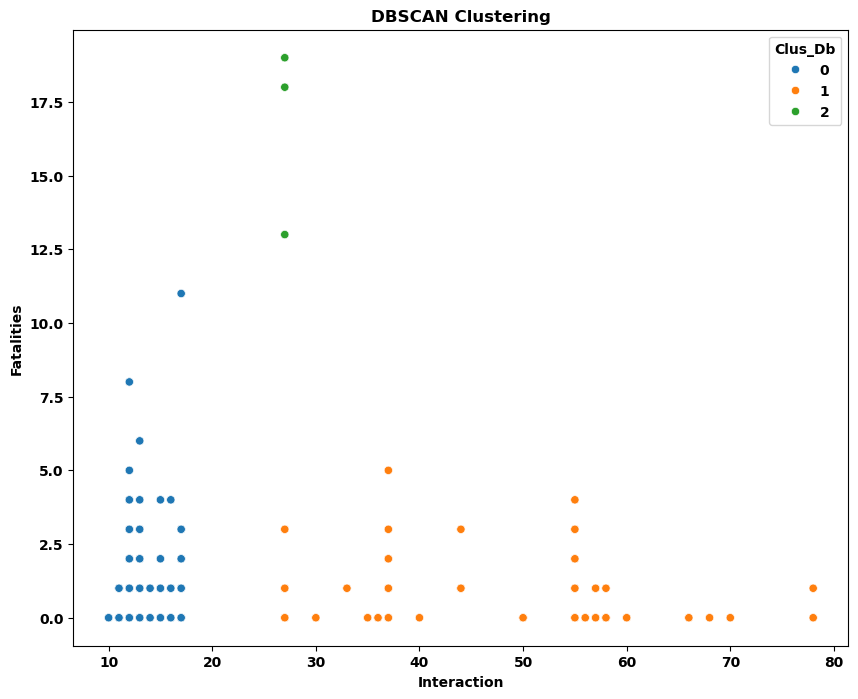

In [61]:
# Visualisasi hasil clustering
plt.figure(figsize=(10, 8))
sns.scatterplot(x='interaction', y='fatalities', hue='Clus_Db', data=data, palette='tab10')
plt.title('DBSCAN Clustering')
plt.xlabel('Interaction')
plt.ylabel('Fatalities')
plt.show()

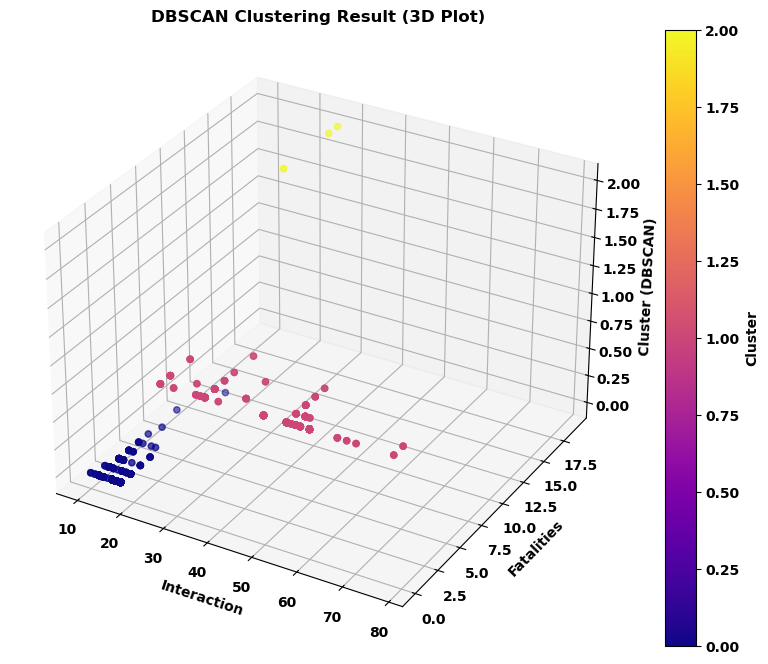

In [62]:
# Definisikan figure
fig = plt.figure(figsize=(10, 8))

# Tambahkan subplot 3D
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
scatter = ax.scatter(data['interaction'], data['fatalities'], data['Clus_Db'], c=data['Clus_Db'], cmap='plasma')

# Label sumbu
ax.set_xlabel('Interaction')
ax.set_ylabel('Fatalities')
ax.set_zlabel('Cluster (DBSCAN)')

# Judul plot
plt.title('DBSCAN Clustering Result (3D Plot)')

# Tampilkan colorbar
plt.colorbar(scatter, label='Cluster')

# Tampilkan plot
plt.show()

In [63]:
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print('Number of clusters:', n_clusters_)
print('Number of noise points:', n_noise_)

Number of clusters: 3
Number of noise points: 0


In [64]:
## Statistik ringkas untuk setiap cluster
cluster_stats = data.groupby('Clus_Db').agg({'interaction': 'mean', 'fatalities': 'mean', 'event_type': 'count'})
cluster_stats.rename(columns={'event_type': 'count'}, inplace=True)
print(cluster_stats)

         interaction  fatalities  count
Clus_Db                                
0          15.480176    0.364170   1362
1          57.519681    0.085568   1753
2          27.000000   16.666667      6


Klaster 0, dengan 1362 data (45,4% dari total data), memiliki tingkat interaksi rata-rata rendah sebesar 15.48 dan tingkat fatalitas yang relatif tinggi, yaitu 0.36.

Klaster 1, yang merupakan klaster terbesar dengan 1753 data (58,43% dari total data), memiliki tingkat interaksi rata-rata yang tinggi sebesar 57.52, namun memiliki tingkat fatalitas yang lebih rendah, hanya 0.09.

Klaster 2, meskipun hanya terdiri dari 6 data (0.02% dari total data), menampilkan tingkat interaksi yang sedang dengan nilai 27.00, namun tingkat fatalitas yang sangat tinggi, mencapai 16.67. Ini menunjukkan bahwa klaster ini memiliki tingkat fatalitas yang jauh lebih tinggi dibandingkan dengan klaster lainnya.

## <div align="center"> EVALUATION </div>

KMEANS

In [39]:
# Evaluasi clustering menggunakan inertia dan silhouette score
inertia = kmeans.inertia_
silhouette_avg = silhouette_score(data[['interaction', 'fatalities']], kmeans.labels_)
print("Inertia:", inertia)
print("Silhouette Score:", silhouette_avg)

Inertia: 18414.0868519479
Silhouette Score: 0.906072972678122


In [40]:
# Hitung Davies-Bouldin Index
davies_bouldin_idx = davies_bouldin_score(data[['interaction', 'fatalities']], kmeans.labels_)

print("Davies-Bouldin Index:", davies_bouldin_idx)

Davies-Bouldin Index: 0.27126668901041434


In [41]:
# Hitung Calinski-Harabasz Index
calinski_harabasz_idx = calinski_harabasz_score(data[['interaction', 'fatalities']], kmeans.labels_)

print("Calinski-Harabasz Index:", calinski_harabasz_idx)

Calinski-Harabasz Index: 120652.96771830006


DBSCAN

In [42]:
# Menghitung nilai silhouette score
silhouette_avg = silhouette_score(data[['interaction', 'fatalities']], data['Clus_Db'])
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.8598824747010627


In [43]:
# Menghitung nilai Davies-Bouldin Index
db_index = davies_bouldin_score(data[['interaction', 'fatalities']], data['Clus_Db'])
print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 0.19363406098404343


In [44]:
# Menghitung nilai Calinski-Harabasz Index
ch_index = calinski_harabasz_score(data[['interaction', 'fatalities']], data['Clus_Db'])
print("Calinski-Harabasz Index:", ch_index)

Calinski-Harabasz Index: 24510.659500477297


_______________________________________

Silhoutte score semakin mendekati 1 semakin baik, untuk mengevaluasi hasil clustering. DBI semakin rendah semakin baik berfungsi untuk mengukur kualitas clustering. Calinski untuk mengukur kualitas clustering berdasarkan kriteria dalam variance antar klaster semakin besar nilainya semakin baik.

Dari hasil evaluasi yang didapatkan dapat dilihat bahwa KMeans baik dalam Silhoutte Score 0.90 dibanding 0.85 sedangkan dalam DBSCAN lebih baik pada Davies Bouldin dan Calinski Harabasz. Hal ini dikarenakan KMeans itu lebih baik dalam memisahkan klaster dan memiliki kejelasan antar klaster yang tinggi dapat dilihat dari persebarannya yang lebih merata, namun memiliki masalah dalam menangani klaster yang distribusi datanya yang memiliki varian berbeda-beda. Sedangkan dalam DBSCAN lebih baik dalam indentifikasi klaster yang memiliki kepadatan yang berbeda-beda.

Dari dataset ini kami merasa lebih baik menggunakan KMeans karena persebaran yang lebih merata dengan nilai silhoutte score yang tinggi sesuai dengan kebutuhan kami.

______________________

## <div align="center"> DEPLOYMENT </div>

Untuk penelitian selanjutnya, model yang telah dibuat ini dapat digunakan untuk memetakan daerah atau wilayah yang memiliki tingkat kerusuhan yang cukup tinggi, sehingga dapat mendeteksi klaster-klaster dari model yang telah dihasilkan.

----

In [49]:
myDate = datetime.datetime.now()
myDevice = str(uuid.uuid1())
print("Name: \t\t{}".format(studentName))
print("NIM: \t\t{}".format(studentNIM))
print("Class: \t\t{}".format(studentClass))
print("End: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Name: 		Angel Lawrensia, Advendhita Putri Cahyani, Muhammad Farhan Zaky, Nova Indah Lumbantoruan
NIM: 		84325, 79028, 83525, 81152
Class: 		CL
End: 		2024-05-17 22:52:39.110494
Device ID: 	7ce080e1-1465-11ef-b719-2c3b7007340a


----

## <div align="center"> Reference </div>

### Input Your Reference Here  (Jika ada):

https://www.kaggle.com/code/karnikakapoor/customer-segmentation-clustering/notebook
https://kaggle.com/code/prashant111/k-means-clustering-with-python
https://www.kaggle.com/code/khotijahs1/k-means-clustering-of-iris-dataset

----